In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [184]:
reddit = pd.read_csv("/kaggle/input/datasets/cosmos98/twitter-and-reddit-sentimental-analysis-dataset/Reddit_Data.csv")
twitter = pd.read_csv("/kaggle/input/datasets/cosmos98/twitter-and-reddit-sentimental-analysis-dataset/Twitter_Data.csv")


In [185]:
print(f"Reddit data columns: {reddit.columns}")
print(f"Twitter data columns: {twitter.columns}")

Reddit data columns: Index(['clean_comment', 'category'], dtype='object')
Twitter data columns: Index(['clean_text', 'category'], dtype='object')


In [186]:
reddit.rename(columns={"clean_comment": "clean_text"}, inplace=True)

In [187]:
print(f"Reddit data columns: {reddit.columns}")

Reddit data columns: Index(['clean_text', 'category'], dtype='object')


In [188]:
data = pd.concat([reddit, twitter], ignore_index=True)

In [189]:
data.head()

,clean_text,category
0,family mormon have never tried explain them t...,1.0
1,buddhism has very much lot compatible with chr...,1.0
2,seriously don say thing first all they won get...,-1.0
3,what you have learned yours and only yours wha...,0.0
4,for your own benefit you may want read living ...,1.0


In [190]:
data.shape

(200229, 2)

In [191]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200229 entries, 0 to 200228
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  200125 non-null  object 
 1   category    200222 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.1+ MB


In [192]:
data.isna().sum()

clean_text    104
category        7
dtype: int64

In [193]:
data = data.dropna()

In [194]:
data.isna().sum()

clean_text    0
category      0
dtype: int64

In [195]:
sample = data.sample(1)
(sample["clean_text"].iloc[0] , sample["category"].iloc[0])

('india west bengal cannot violate the mccmamata said ssc empanelled teachers 28th days hunger strikeshe assured them that the issue would resolvedpeople says that she wants ensure free passage for modis kolkata visit 3rd april  ',
 np.float64(1.0))

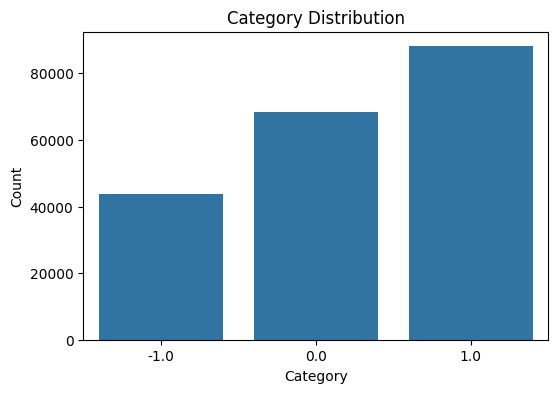

In [196]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="category")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [197]:
data.duplicated().sum()

np.int64(410)

In [198]:
data[data.duplicated()]

,clean_text,category
375,,0.0
392,,0.0
617,aurum mom,0.0
651,,0.0
1222,,0.0
...,...,...
171338,what this,0.0
172959,tell something new,1.0
177777,true that,1.0
184768,spot,0.0


In [199]:
data.drop_duplicates(inplace=True)

In [200]:
data.duplicated().sum()

np.int64(0)

In [201]:
data[(data['clean_text'].str.strip() == '')]

,clean_text,category
181,,0.0
4432,\n,0.0
10592,,0.0
16173,,0.0
32149,\n,0.0
34959,,0.0


In [202]:
data = data[~(data['clean_text'].str.strip() == '')]

In [203]:
data["clean_text"] = data["clean_text"].str.lower()
data.head()

,clean_text,category
0,family mormon have never tried explain them t...,1.0
1,buddhism has very much lot compatible with chr...,1.0
2,seriously don say thing first all they won get...,-1.0
3,what you have learned yours and only yours wha...,0.0
4,for your own benefit you may want read living ...,1.0


In [204]:
data[data["clean_text"].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_text,category
0,family mormon have never tried explain them t...,1.0
1,buddhism has very much lot compatible with chr...,1.0
2,seriously don say thing first all they won get...,-1.0
3,what you have learned yours and only yours wha...,0.0
4,for your own benefit you may want read living ...,1.0
...,...,...
200221,engine growth modi unveils indias first 12000 ...,1.0
200222,modi promised 2014 lok sabha elections that be...,1.0
200224,why these 456 crores paid neerav modi not reco...,-1.0
200226,did you cover her interaction forum where she ...,0.0


In [205]:
data['clean_text'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(111673)

In [206]:
data['clean_text']= data['clean_text'].str.strip()
data['clean_text'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [207]:
data["special_char_count"] = data["clean_text"].str.count(r"[^a-zA-Z0-9\s]")
data.head()

,clean_text,category,special_char_count
0,family mormon have never tried explain them th...,1.0,0
1,buddhism has very much lot compatible with chr...,1.0,0
2,seriously don say thing first all they won get...,-1.0,0
3,what you have learned yours and only yours wha...,0.0,0
4,for your own benefit you may want read living ...,1.0,0


In [208]:
data.groupby("category").count()

,clean_text,special_char_count
category,,
-1.0,43755,43755
0.0,67955,67955
1.0,87992,87992


In [209]:
data["clean_text"] = data["clean_text"].str.replace(
    r"[^a-zA-Z0-9\s]",
    "",
    regex=True
)
data = data.drop(columns=["special_char_count"])


In [210]:
total_special_chars = data["clean_text"].str.count(r"[^a-zA-Z0-9\s]").sum()
print(total_special_chars)

0


In [211]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = data[data['clean_text'].str.contains(url_pattern, regex=True)]
comments_with_urls.head()

,clean_text,category


In [212]:
data["clean_text"] = data["clean_text"].str.replace(r"\n", " ", regex=True)

In [213]:
data["word_count"] = data["clean_text"].apply(lambda x: len(x.split(" ")))
data.head()

,clean_text,category,word_count
0,family mormon have never tried explain them th...,1.0,39
1,buddhism has very much lot compatible with chr...,1.0,196
2,seriously don say thing first all they won get...,-1.0,86
3,what you have learned yours and only yours wha...,0.0,29
4,for your own benefit you may want read living ...,1.0,112


In [214]:
data["word_count"].describe()

count    199702.000000
mean         21.868589
std          26.543257
min           1.000000
25%          10.000000
50%          18.000000
75%          29.000000
max        1307.000000
Name: word_count, dtype: float64

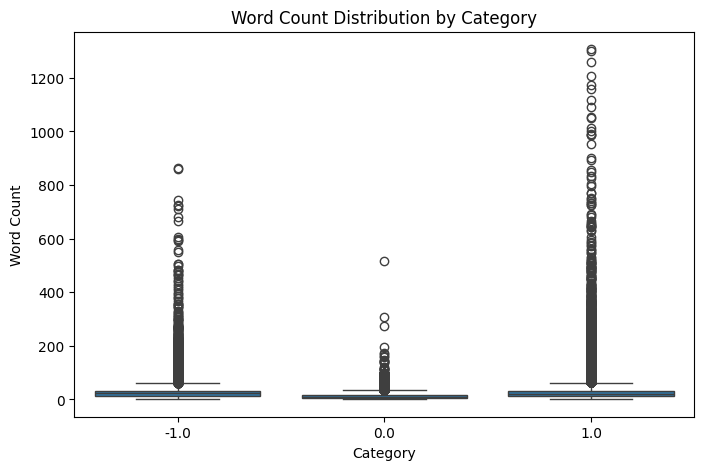

In [215]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="category",
    y="word_count"
)

plt.title("Word Count Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Word Count")

plt.show()

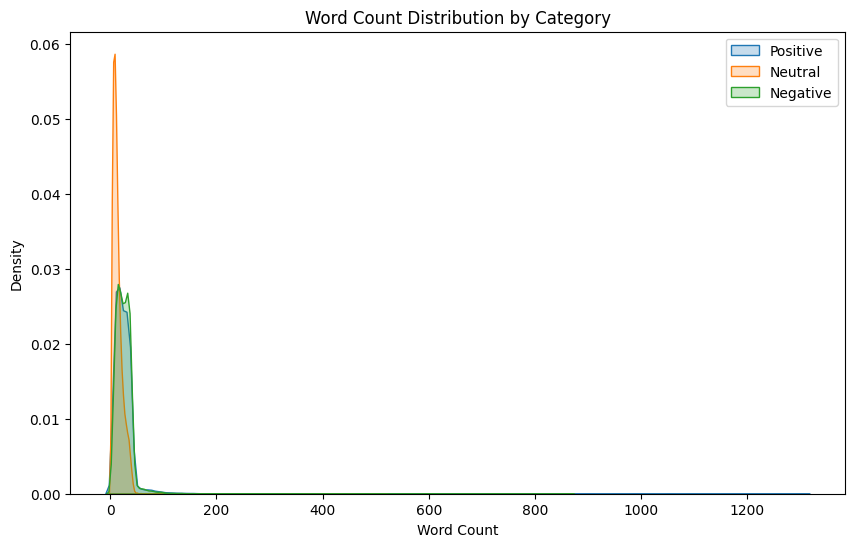

In [216]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data[data['category'] == 1]['word_count'], label='Positive', fill=True)
sns.kdeplot(data[data['category'] == 0]['word_count'], label='Neutral', fill=True)
sns.kdeplot(data[data['category'] == -1]['word_count'], label='Negative', fill=True)
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()
     

In [217]:
!pip install nltk

In [218]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [219]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english")) 
data["stopword_count"] = data["clean_text"].apply(
    lambda text: sum(
        word in stop_words
        for word in str(text).split()
    )
)
data.head()

,clean_text,category,word_count,stopword_count
0,family mormon have never tried explain them th...,1.0,39,13
1,buddhism has very much lot compatible with chr...,1.0,196,59
2,seriously don say thing first all they won get...,-1.0,86,40
3,what you have learned yours and only yours wha...,0.0,29,15
4,for your own benefit you may want read living ...,1.0,112,45


/tmp/ipykernel_58/2260064472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


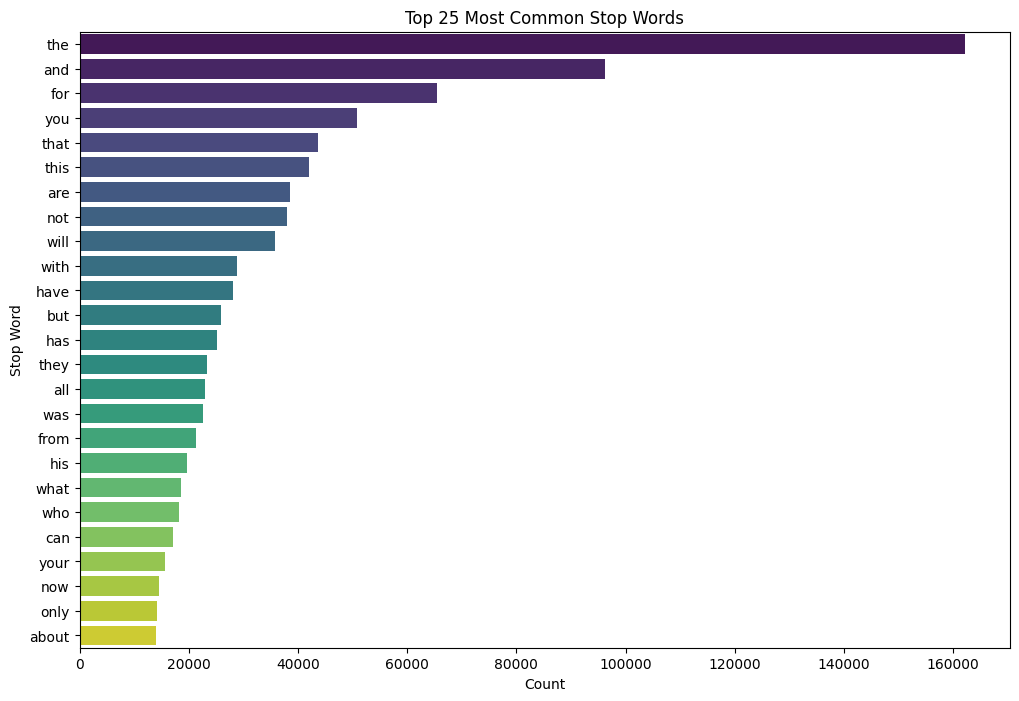

In [220]:

from collections import Counter
all_stop_words = [word for comment in data['clean_text'] for word in comment.split() if word in stop_words]
most_common_stop_words = Counter(all_stop_words).most_common(25)
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()


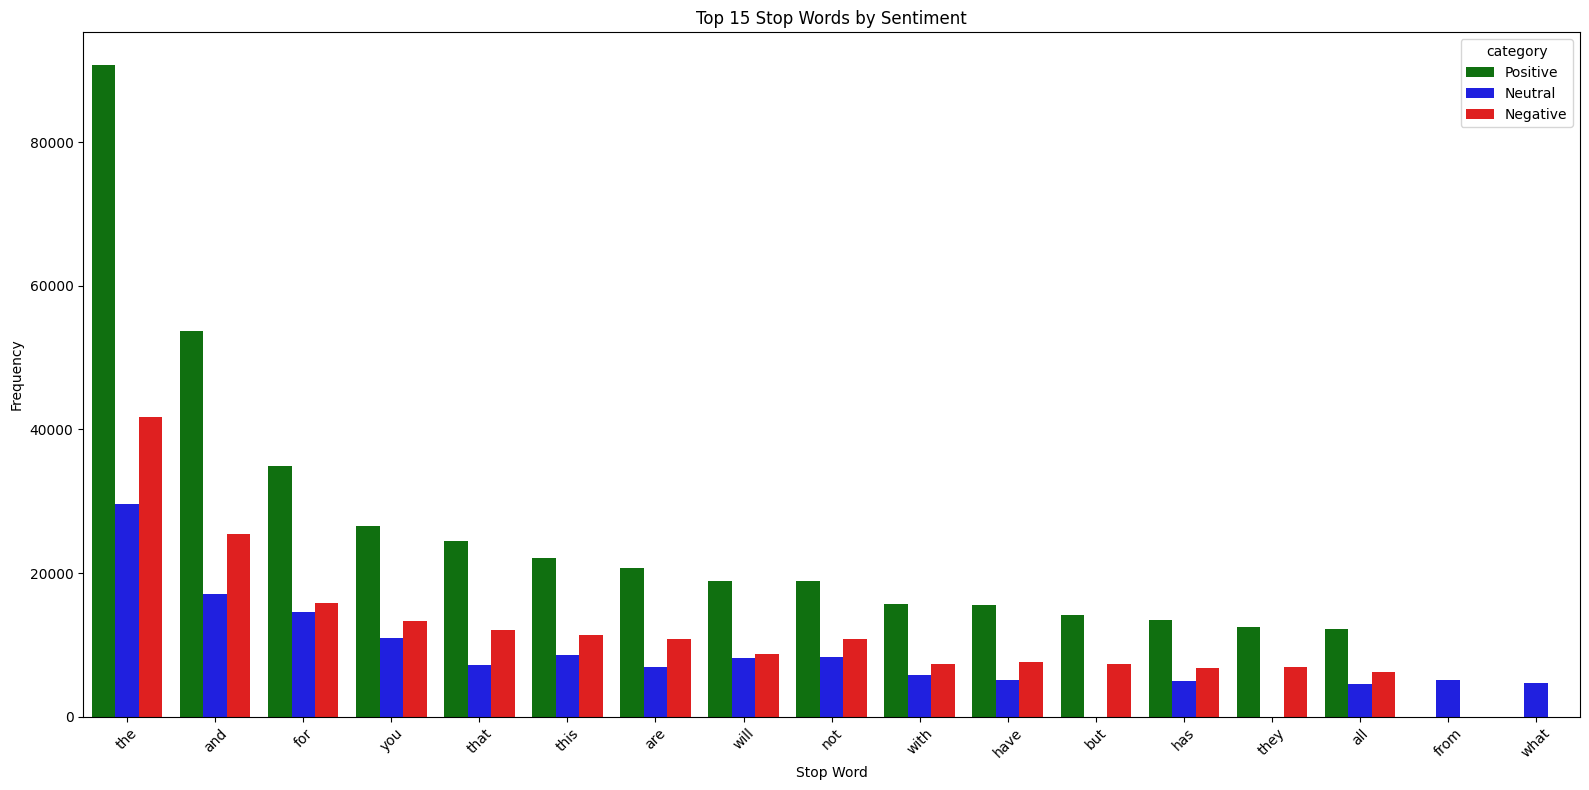

In [221]:
stop_word_positive = [
    stop
    for comment in data.loc[data["category"] == 1, "clean_text"]
    for stop in str(comment).split()
    if stop.lower() in stop_words
]

stop_word_negative = [
    stop
    for comment in data.loc[data["category"] == -1, "clean_text"]
    for stop in str(comment).split()
    if stop.lower() in stop_words
]

stop_word_neutral = [
    stop
    for comment in data.loc[data["category"] == 0, "clean_text"]
    for stop in str(comment).split()
    if stop.lower() in stop_words
]
positive = Counter(stop_word_positive).most_common(15)
neutral = Counter(stop_word_neutral).most_common(15)
negative = Counter(stop_word_negative).most_common(15)

df_pos = pd.DataFrame(positive, columns=["word", "count"])
df_pos["category"] = "Positive"

df_neu = pd.DataFrame(neutral, columns=["word", "count"])
df_neu["category"] = "Neutral"

df_neg = pd.DataFrame(negative, columns=["word", "count"])
df_neg["category"] = "Negative"

plot_df = pd.concat([df_pos, df_neu, df_neg], ignore_index=True)

plt.figure(figsize=(16, 8))

sns.barplot(
    data=plot_df,
    x="word",
    y="count",
    hue="category",
    palette={
        "Positive": "green",
        "Neutral": "blue",
        "Negative": "red"
    }
)

plt.title("Top 15 Stop Words by Sentiment")
plt.xlabel("Stop Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [223]:
stop_words = stop_words - {"not", "no", "but"}

data["clean_text"] = data["clean_text"].apply(
    lambda x: " ".join(
        word for word  in str(x).split()
        if word not in stop_words
    )
)

In [224]:
total_stop_words = data["clean_text"].apply(
    lambda x: sum(word in stop_words for word in str(x).split())
).sum()
total_stop_words

np.int64(0)

In [227]:
import string

data["clean_text"] = data["clean_text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [228]:
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [232]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
lemmatizer = WordNetLemmatizer()

In [233]:

def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def lemmatize_text(text):
    words = nltk.word_tokenize(str(text))
    pos_tags = nltk.pos_tag(words)

    return " ".join(
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    )

data["clean_text"] = data["clean_text"].apply(lemmatize_text)

In [236]:
data = data[["clean_text","category"]]

In [237]:
data.sample(4)

,clean_text,category
176748,indian express editorial 30032019 describes ou...,-1.0
44962,yeah bjp less seats 2019 modi lose varanasi am...,-1.0
178048,soon tell,0.0
26851,memx meme stock hehe thanks news,1.0


In [238]:
data.to_csv("/kaggle/working/clean_data.csv", index=False)